## SPTL Data pull

In [251]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from statsmodels.tsa.stattools import adfuller
from matplotlib.dates import DateFormatter

# Using Yahoo Finance ticker 
ticker = 'SPTL'

# Fetch data for 2023
sptl_data = yf.download(ticker, start='2023-01-01', end='2023-12-31')

# Calculating daily returns 
# backwards differencing:
sptl_data['Daily Return'] = sptl_data['Close'].pct_change()

# forward differencing: 
# sptl_data['Daily Return'] = (sptl_data['Close'].shift(-1) - sptl_data['Close']) / sptl_data['Close']

closing_prices = sptl_data[['Close', 'Daily Return']]


[*********************100%***********************]  1 of 1 completed


## EFFR Data pull


In [252]:
effr_data = pd.read_excel("/Users/carlo/Documents/UCL/Algorithmic_Trading1/coursework/data/EFFR_index2018.2024.xlsx")
print("Dataset loaded successfully!")


# Convert "Effective Date" to datetime format
effr_data['Effective Date'] = pd.to_datetime(effr_data['Effective Date'])

# Convert "Rate (%)" to a daily rate
effr_data['Daily Rate'] = (effr_data['Rate (%)'] / 252) / 100


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning:

Workbook contains no default style, apply openpyxl's default



Dataset loaded successfully!


## Fill EFFR Dataset

In [253]:
# fill the days where there is no EFFR rate, bc its a holiday or weekend
# First, create a full business-day date range for 2023
full_dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='B')  # 'B' = business day

# Set the index to Effective Date (make sure it's datetime)
effr_data['Effective Date'] = pd.to_datetime(effr_data['Effective Date'])
effr_data = effr_data.set_index('Effective Date')

# Reindex to full calendar, forward fill missing values
effr_filled = effr_data.reindex(full_dates).ffill().reset_index()

# Rename index back to Effective Date
effr_filled.rename(columns={'index': 'Effective Date'}, inplace=True)

## Flatten MultiIndex and Create Merged Dataframe

In [254]:
# Flatten MultiIndex columns 
sptl_data.columns = sptl_data.columns.get_level_values(0)

# Flatten index if MultiIndex
sptl_data = sptl_data.reset_index()  # Converts Date index to column
effr_filled = effr_filled.reset_index()  # safety

# Ensure date columns are in datetime format
sptl_data['Date'] = pd.to_datetime(sptl_data['Date'])
effr_filled['Effective Date'] = pd.to_datetime(effr_filled['Effective Date'])

#  merging
merged_data = pd.merge(sptl_data, effr_filled, left_on='Date', right_on='Effective Date', how='left')

# Computing daily excess returns
merged_data['Daily Excess Return'] = merged_data['Daily Return'] - merged_data['Daily Rate']

output_path = "/Users/carlo/Documents/UCL/Algorithmic_Trading1/coursework/data/SPTL_daily_returns.xlsx"
merged_data.to_excel(output_path, index=False)

print(f"Updated dataset with daily returns & excess returns saved at: {output_path}")


Updated dataset with daily returns & excess returns saved at: /Users/carlo/Documents/UCL/Algorithmic_Trading1/coursework/data/SPTL_daily_returns.xlsx


In [255]:
print(merged_data[['Date', 'Close', 'Daily Return', 'Rate (%)', 'Daily Rate', 'Daily Excess Return']].head(10))

        Date      Close  Daily Return  Rate (%)  Daily Rate  \
0 2023-01-03  27.326912           NaN      4.33    0.000172   
1 2023-01-04  27.669302      0.012529      4.33    0.000172   
2 2023-01-05  27.780350      0.004013      4.33    0.000172   
3 2023-01-06  28.261557      0.017322      4.33    0.000172   
4 2023-01-09  28.400368      0.004912      4.33    0.000172   
5 2023-01-10  27.983934     -0.014663      4.33    0.000172   
6 2023-01-11  28.372602      0.013889      4.33    0.000172   
7 2023-01-12  28.890823      0.018265      4.33    0.000172   
8 2023-01-13  28.640966     -0.008648      4.33    0.000172   
9 2023-01-17  28.474392     -0.005816      4.33    0.000172   

   Daily Excess Return  
0                  NaN  
1             0.012358  
2             0.003842  
3             0.017150  
4             0.004740  
5            -0.014835  
6             0.013717  
7             0.018093  
8            -0.008820  
9            -0.005988  


## Q1: Time Series Prep 
Plot SPTL return time series, the EFFR, and the excess return per unit of SPTL

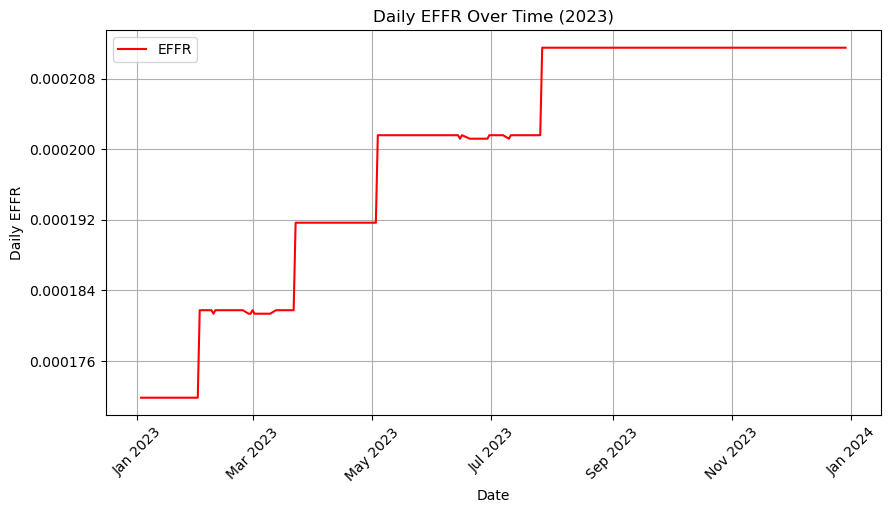

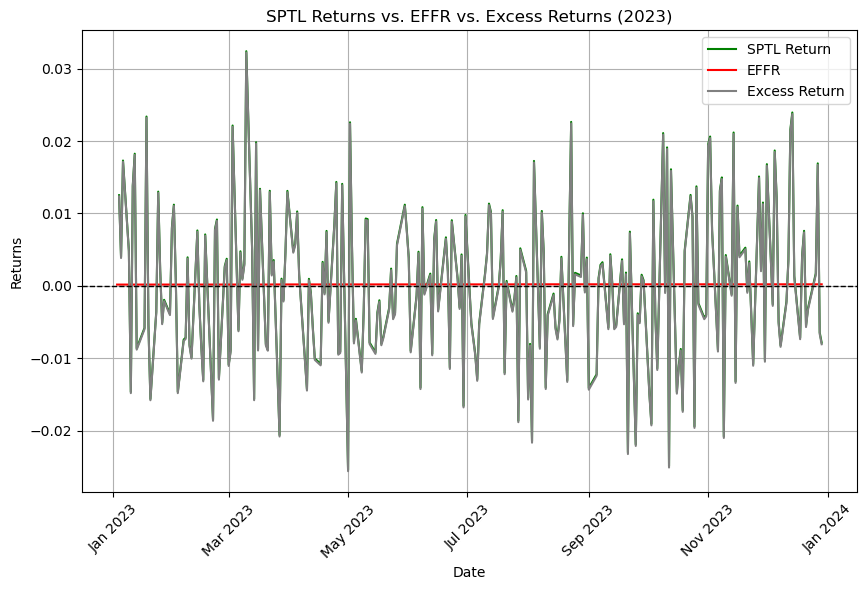

In [256]:

plt.figure(figsize=(10, 5))
plt.plot(merged_data['Date'], merged_data['Daily Rate'], color='red', label='EFFR')
plt.title("Daily EFFR Over Time (2023)")
plt.xlabel("Date")
plt.ylabel("Daily EFFR")
plt.legend()
plt.grid(True)
ax = plt.gca()
date_formatter = mdates.DateFormatter('%b %Y')
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
ax.yaxis.set_major_locator(MaxNLocator(6))
plt.show()

# Plotting SPTL Return vs. EFFR vs. Daily Excess Return 
plt.figure(figsize=(10, 6))
plt.plot(merged_data['Date'], merged_data['Daily Return'], label='SPTL Return', color='green')
plt.plot(merged_data['Date'], merged_data['Daily Rate'], label='EFFR', color='red')
plt.plot(merged_data['Date'], merged_data['Daily Excess Return'], label='Excess Return', color='gray')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("SPTL Returns vs. EFFR vs. Excess Returns (2023)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)
plt.show()


## As a Benchmark: Buy & Hold Strategy

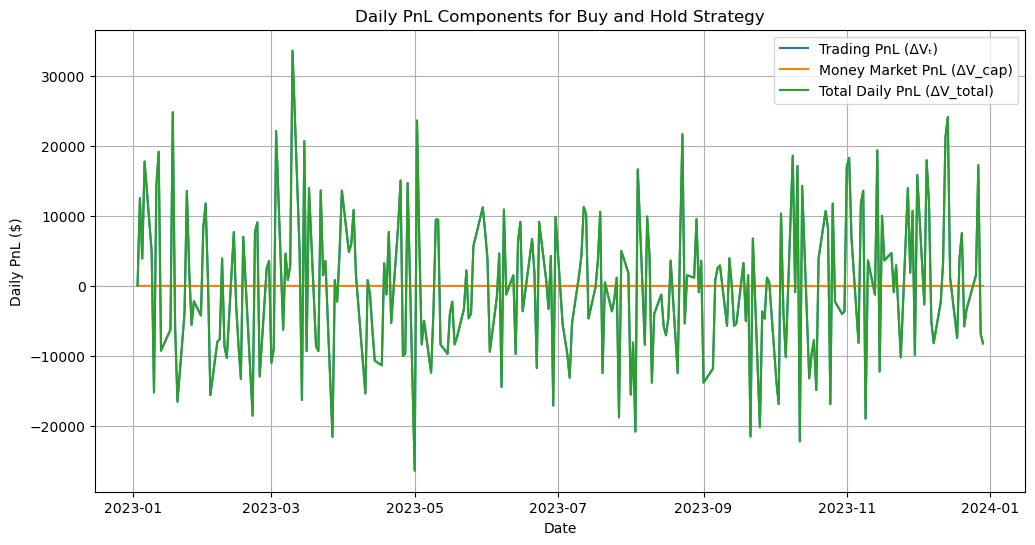

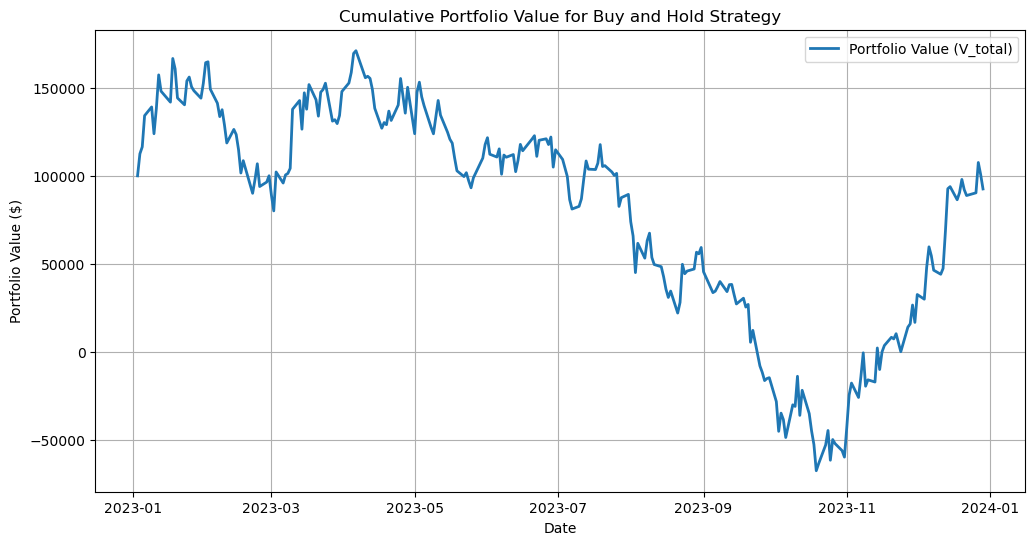

Final portfolio value: $92,560.58
Total return: -7.44%


In [257]:


# Parameters
V0 = 100000      # initial capital in dollars
L = 10           # leverage

# Compute the number of units purchased at t=0 using maximum allowed leverage
initial_price = merged_data['Close'].iloc[0]
units = (V0 * L) / initial_price

# Prepare lists to store results
n = len(merged_data)
theta = [0] * n         # Dollar value of position at each day
margin = [0] * n        # Margin used = theta / L
dV_trade = [0] * n      # Daily trading PnL (ΔV_t)
dV_cap = [0] * n        # Daily money-market (capital) PnL (ΔV_cap)
dV_total = [0] * n      # Total daily PnL (ΔV_total)
V_total = [0] * n       # Portfolio total value (V_total)

# Set initial conditions (day 0)
theta[0] = units * merged_data['Close'].iloc[0]
margin[0] = theta[0] / L
V_total[0] = V0
dV_trade[0] = 0
dV_cap[0] = 0
dV_total[0] = 0

# Loop over the days (starting from day 1)
for i in range(1, n):
    price = merged_data['Close'].iloc[i]
    theta[i] = units * price
    margin[i] = theta[i] / L
    
    # risk-free rate and asset return for day i
    r_ft = merged_data['Daily Rate'].iloc[i-1]
    daily_ret = merged_data['Daily Return'].iloc[i]
    # If  daily return  NaN (e.g. for the first row), assume 0
    if pd.isna(daily_ret):
        daily_ret = 0
        
    # Trading PnL
    dV_trade[i] = (daily_ret - r_ft) * theta[i]
    # Money market PnL
    dV_cap[i] = (V_total[i-1] - margin[i-1]) * r_ft

    # Total daily PnL is the sum of trading and money-market PnL
    dV_total[i] = dV_trade[i] + dV_cap[i]
    V_total[i] = V_total[i-1] + dV_total[i]

merged_data['Theta'] = theta
merged_data['Margin'] = margin
merged_data['dV_trade'] = dV_trade
merged_data['dV_cap'] = dV_cap
merged_data['dV_total'] = dV_total
merged_data['V_total'] = V_total

plt.figure(figsize=(12, 6))
plt.plot(merged_data['Date'], merged_data['dV_trade'], label='Trading PnL (ΔVₜ)')
plt.plot(merged_data['Date'], merged_data['dV_cap'], label='Money Market PnL (ΔV_cap)')
plt.plot(merged_data['Date'], merged_data['dV_total'], label='Total Daily PnL (ΔV_total)')
plt.xlabel('Date')
plt.ylabel('Daily PnL ($)')
plt.title('Daily PnL Components for Buy and Hold Strategy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(merged_data['Date'], merged_data['V_total'], label='Portfolio Value (V_total)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.title('Cumulative Portfolio Value for Buy and Hold Strategy')
plt.legend()
plt.grid(True)
plt.show()


final_value = V_total[-1]
initial_value = V_total[0]
total_return = (final_value - initial_value) / initial_value

print(f"Final portfolio value: ${final_value:,.2f}")
print(f"Total return: {total_return * 100:.2f}%")

## Q2: Strategy 1, Momentum (15 days)

/var/folders/kw/93s8330s3377g2r904bchvtm0000gn/T/ipykernel_24672/3985488556.py:9: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True  True  True  True  True False False False False False
 False False False False False False False False False False False False
 False False False False False False False  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False False  True False  True
 False False  True False False False False False False False  True  True
 False  True  True  True False False False False False False False False
 False False False False False False False False False False  True  True
  True  True  True  True  True  True False  True  True  True  True  True
  True  True False False False False False False False False False False
  True False  True False False  True False  True  True Fal

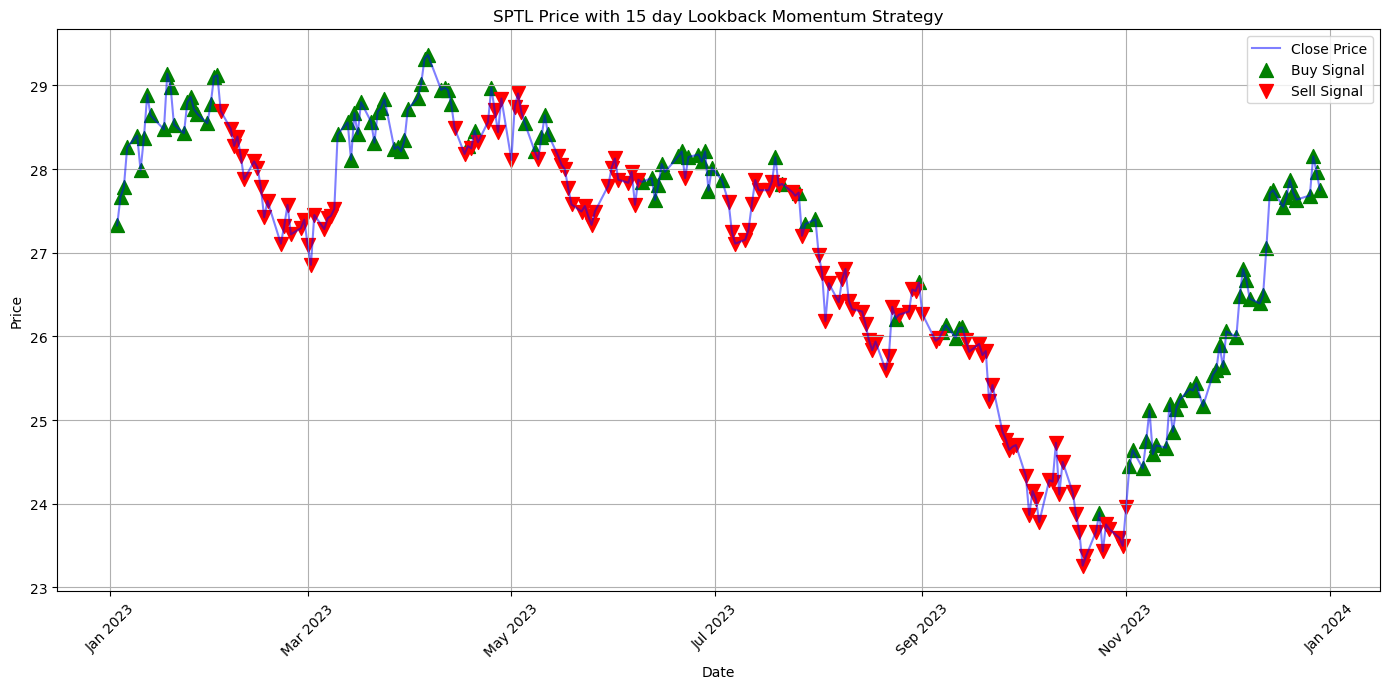

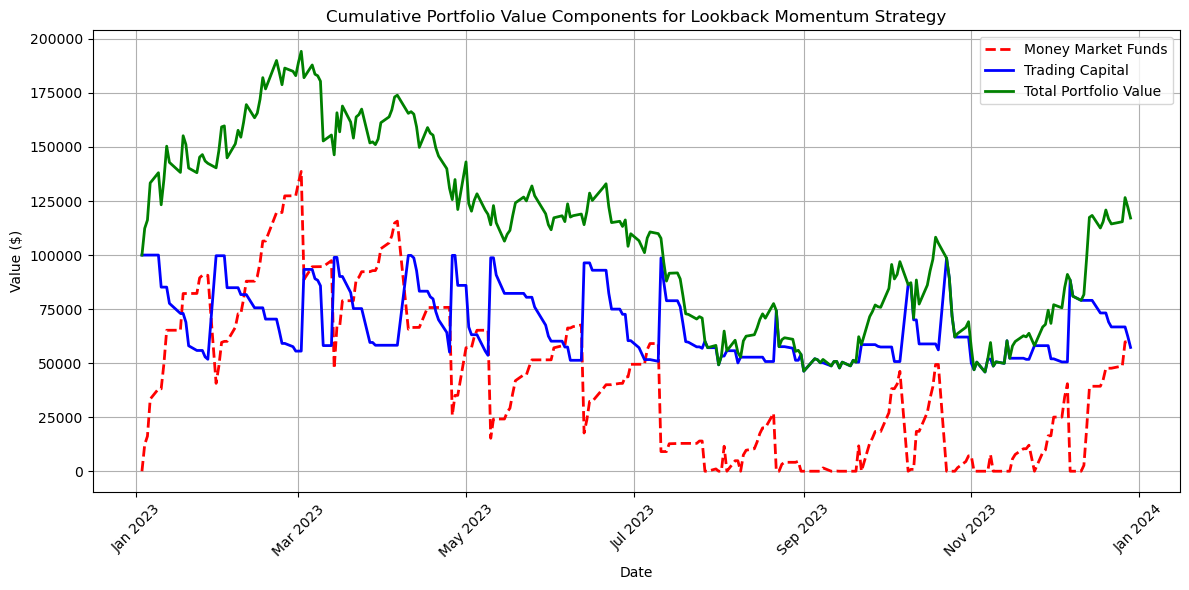

Revised Momentum Strategy - Final portfolio value: $117,137.89
Revised Momentum Strategy - Total return: 17.14%
Revised Momentum Strategy - Sharpe Ratio: 0.75


In [258]:
lookback_period = 15  

#  momentum signals:
# For each day starting from index = lookback_period, compare today's Close with the Close from 'lookback_period' days ago.
# If today's price > lagged price, momentum is positive → signal = +1 (buy);
# If today's price <= lagged price, momentum is negative → signal = -1 (short).
# For days without enough history, default to a long signal (+1).
merged_data['momentum_signal'] = 1  # default signal for early days
merged_data.loc[lookback_period:, 'momentum_signal'] = merged_data.loc[lookback_period:, 'Close'] > merged_data['Close'].shift(lookback_period).loc[lookback_period:]
merged_data['momentum_signal'] = merged_data['momentum_signal'].apply(lambda x: 1 if x == True else -1)

V0_mom = 100000  
L = 10           
n = len(merged_data)

trading_cap = [0] * n      # trading capital (amount allocated for leveraged exposure)
money_market = [0] * n     # money market funds (profits accruing at the risk-free rate)
theta_mom = [0] * n        # actual trading exposure (position size) = signal * trading_cap * L
dV_trade_mom = [0] * n     # trading PnL for each day
dV_cap_mom = [0] * n       # money market PnL (interest earned on segregated profits)
dV_total_mom = [0] * n     # total daily PnL (trading + money market)
V_total_mom = [0] * n      # total portfolio value = trading capital + money market funds

#  initial conditions for day 0
trading_cap[0] = V0_mom                        
money_market[0] = 0                            
theta_mom[0] = merged_data['momentum_signal'].iloc[0] * trading_cap[0] * L  # initial exposure = 100k*10 = 1,000,000
V_total_mom[0] = trading_cap[0] + money_market[0]  # initial portfolio value = 100k
dV_trade_mom[0] = 0
dV_cap_mom[0] = 0
dV_total_mom[0] = 0


for i in range(1, n):
    theta_mom[i] = merged_data['momentum_signal'].iloc[i-1] * trading_cap[i-1] * L
    
    r_ft = merged_data['Daily Rate'].iloc[i-1]
    daily_ret = merged_data['Daily Return'].iloc[i]
    if pd.isna(daily_ret):
        daily_ret = 0
    
 
    dV_trade = (daily_ret - r_ft) * theta_mom[i]
    dV_trade_mom[i] = dV_trade
    
    # Compute money market PnL: interest earned on yesterday's money market funds.
    dV_cap = money_market[i-1] * r_ft
    dV_cap_mom[i] = dV_cap
    
    # Update trading capital:
    # - On a profit day (dV_trade > 0): profit is diverted to the money market (trading capital remains unchanged).
    # - On a loss day (dV_trade < 0): the loss reduces the trading capital.
    if dV_trade > 0:
        trading_cap[i] = trading_cap[i-1]
    else:
        trading_cap[i] = trading_cap[i-1] + dV_trade
    
    # Update the money market funds:
    # - On a profit day, add the profit plus its interest.
    # - On a loss day,  only the interest on the existing money market funds.
    if dV_trade > 0:
        money_market[i] = money_market[i-1] + dV_trade + dV_cap
    else:
        money_market[i] = money_market[i-1] + dV_cap

    # Rebalance: If trading capital is at or below 50k, pull funds from the money market to top it up,
    #  do not exceed a total trading capital of 100k and no more than 50k can be transferred.
    if trading_cap[i] <= 50000:
        # Amount needed to reach 100k
        required_top_up = 100000 - trading_cap[i]
        # Limit the top-up to a maximum of 50k and the available funds in the money market.
        top_up = min(required_top_up, 50000, money_market[i])
        trading_cap[i] += top_up
        money_market[i] -= top_up
    
    # Total daily PnL is the sum of the trading and money market components.
    dV_total = dV_trade + dV_cap
    dV_total_mom[i] = dV_total
    
    # Total portfolio value is the sum of the current trading capital and money market funds.
    V_total_mom[i] = trading_cap[i] + money_market[i]

#  computed metrics to merged_data for plotting and analysis
merged_data['Theta_mom'] = theta_mom
merged_data['Trading_Cap'] = trading_cap
merged_data['Money_Market'] = money_market
merged_data['dV_trade_mom'] = dV_trade_mom
merged_data['dV_cap_mom'] = dV_cap_mom
merged_data['dV_total_mom'] = dV_total_mom
merged_data['V_total_mom'] = V_total_mom

# ---------------------------
plt.figure(figsize=(14, 7))
plt.plot(merged_data['Date'], merged_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'SPTL Price with {lookback_period} day Lookback Momentum Strategy')
buy_mom = merged_data[merged_data['momentum_signal'] == 1]
sell_mom = merged_data[merged_data['momentum_signal'] == -1]
plt.scatter(buy_mom['Date'], buy_mom['Close'], marker='^', color='green', s=100, label='Buy Signal')
plt.scatter(sell_mom['Date'], sell_mom['Close'], marker='v', color='red', s=100, label='Sell Signal')
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))  
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

# ---------------------------
# Plot the cumulative portfolio value components:
# Money Market funds (red, dashed), Trading Capital (blue, solid), and Total Portfolio Value (green, solid)
plt.figure(figsize=(12, 6))
plt.plot(merged_data['Date'], merged_data['Money_Market'], label='Money Market Funds', linewidth=2, color='red', linestyle='--')
plt.plot(merged_data['Date'], merged_data['Trading_Cap'], label='Trading Capital', linewidth=2, color='blue', linestyle='-')
plt.plot(merged_data['Date'], merged_data['V_total_mom'], label='Total Portfolio Value', linewidth=2, color='green', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.title('Cumulative Portfolio Value Components for Lookback Momentum Strategy')
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))  
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

final_value_mom = V_total_mom[-1]
initial_value_mom = V_total_mom[0]
total_return_mom = (final_value_mom - initial_value_mom) / initial_value_mom
print(f"Revised Momentum Strategy - Final portfolio value: ${final_value_mom:,.2f}")
print(f"Revised Momentum Strategy - Total return: {total_return_mom * 100:.2f}%")




merged_data['mom_daily_return'] = merged_data['dV_total_mom'] / merged_data['V_total_mom'].shift(1)

mom_daily_return = merged_data['mom_daily_return'].dropna()

sharpe_ratio = (mom_daily_return.mean() / mom_daily_return.std()) * np.sqrt(252)
print(f"Revised Momentum Strategy - Sharpe Ratio: {sharpe_ratio:.2f}")


In [259]:
# %% Augmented Dickey-Fuller Test on Daily Excess Return



excess_return_series = merged_data['Daily Excess Return'].dropna()

# Run the ADF test
adf_result = adfuller(excess_return_series)

print("Augmented Dickey-Fuller Test:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

print("Number of Lags Used: ", adf_result[2])
print("Number of Observations Used: ", adf_result[3])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")


Augmented Dickey-Fuller Test:
ADF Statistic: -18.0654
p-value: 0.0000
Number of Lags Used:  0
Number of Observations Used:  248
Critical Values:
   1%: -3.4570
   5%: -2.8733
   10%: -2.5730


## Q2: Strategy 2, Daily Trend Following

/var/folders/kw/93s8330s3377g2r904bchvtm0000gn/T/ipykernel_24672/2264162598.py:17: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/var/folders/kw/93s8330s3377g2r904bchvtm0000gn/T/ipykernel_24672/2264162598.py:133: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/var/folders/kw/93s8330s3377g2r904bchvtm0000gn/T/ipykernel_24672/2264162598.py:134: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



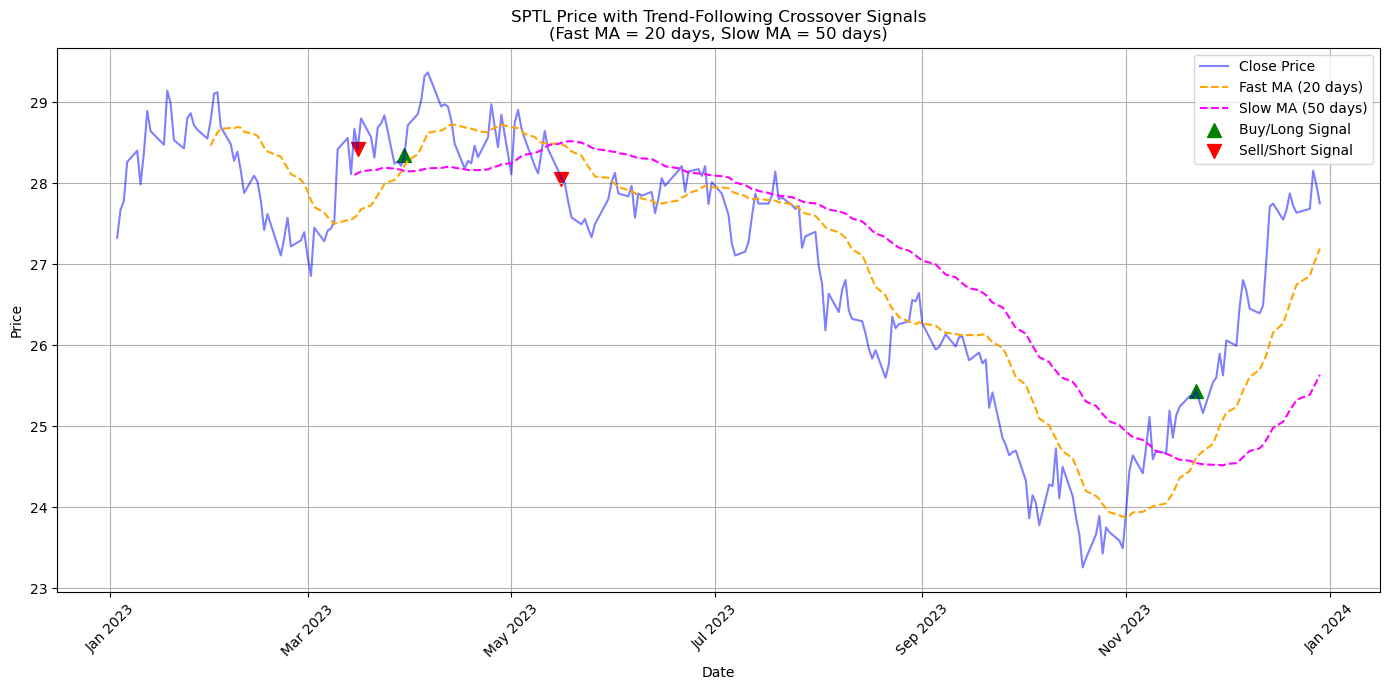

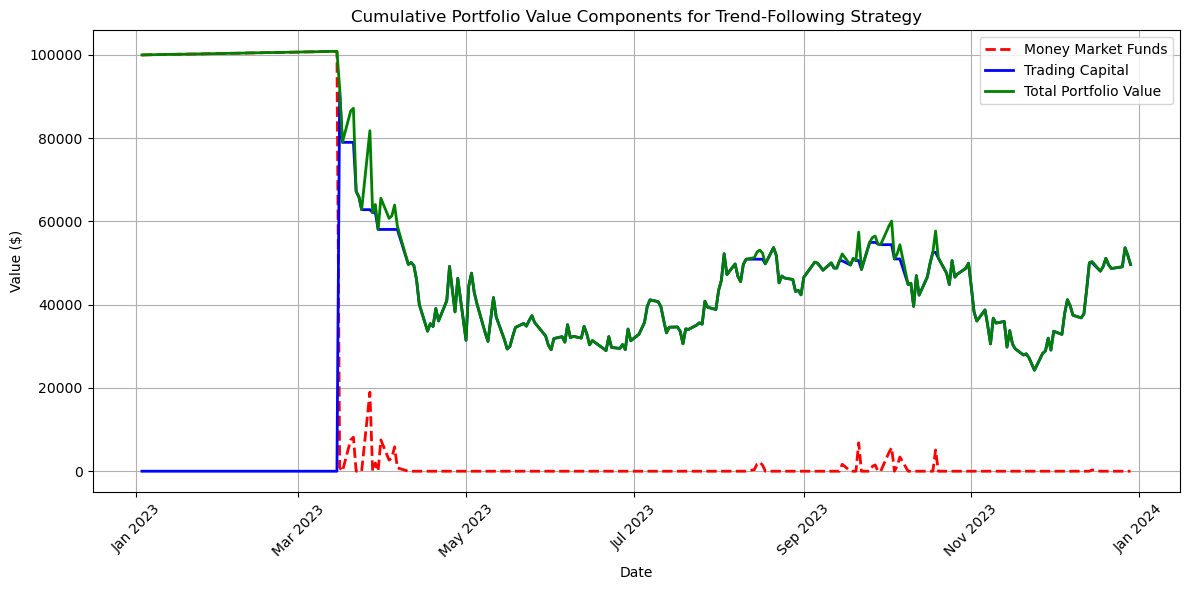

Trend-Following Strategy - Final portfolio value: $49,647.89
Trend-Following Strategy - Total return: -50.35%
Total number of Buy trades executed: 3
Total number of Short trades executed: 2
Trend-Following Strategy - Sharpe Ratio: 1.28


In [260]:

# Parameters for moving averages
fast_window = 20
slow_window = 50

merged_data['fast_ma'] = merged_data['Close'].rolling(window=fast_window, min_periods=fast_window).mean()
merged_data['slow_ma'] = merged_data['Close'].rolling(window=slow_window, min_periods=slow_window).mean()

#  trend signals:
# For days with enough data (starting from slow_window index),
# if fast_ma > slow_ma then trend_signal = +1 (buy/long), otherwise -1 (sell/short).
# For days without enough history (i < slow_window), no trading signal is generated.
merged_data['trend_signal'] = np.nan  # initialize with NaN for clarity
merged_data.loc[slow_window:, 'trend_signal'] = np.where(
    merged_data.loc[slow_window:, 'fast_ma'] > merged_data.loc[slow_window:, 'slow_ma'], 1, -1
)
# fill earlier days with +1.
merged_data['trend_signal'].fillna(1, inplace=True)

#  cross_signal to detect actual crossovers:
# A change from -1 to +1 yields a +2 (buy signal) and from +1 to -1 yields a -2 (sell signal).
merged_data['cross_signal'] = merged_data['trend_signal'].diff()

V0_tf = 100000  
L = 10          
n = len(merged_data)

trading_cap_tf = [0] * n      # trading capital allocated for leveraged exposure
money_market_tf = [0] * n     # money market funds (idle capital + accrued profits)
theta_tf = [0] * n            # trading exposure = trend_signal * trading_capital * L
dV_trade_tf = [0] * n         # trading PnL for each day
dV_cap_tf = [0] * n           # money market PnL (interest on funds)
dV_total_tf = [0] * n         # total daily PnL (trading + money market)
V_total_tf = [0] * n          # total portfolio value = trading capital + money market funds

#  trade counters
buy_count = 0
short_count = 0

#  initial conditions for day 0: no trading yet, all funds in money market.
trading_cap_tf[0] = 0            # no funds allocated to trading
money_market_tf[0] = V0_tf       # entire capital is in money market
theta_tf[0] = 0                  # no exposure
V_total_tf[0] = money_market_tf[0]  # portfolio equals money market funds
dV_trade_tf[0] = 0
dV_cap_tf[0] = 0
dV_total_tf[0] = 0

# Loop over days to simulate the strategy.
for i in range(1, n):
    r_ft = merged_data['Daily Rate'].iloc[i-1]
    daily_ret = merged_data['Daily Return'].iloc[i]
    if pd.isna(daily_ret):
        daily_ret = 0

    if i < slow_window:
        theta_tf[i] = 0
        dV_trade_tf[i] = 0
        dV_cap = money_market_tf[i-1] * r_ft
        dV_cap_tf[i] = dV_cap
        money_market_tf[i] = money_market_tf[i-1] + dV_cap
        trading_cap_tf[i] = 0
        V_total_tf[i] = money_market_tf[i]
        dV_total_tf[i] = dV_trade_tf[i] + dV_cap_tf[i]
    else:
        if (i == slow_window) or (i > slow_window and merged_data['trend_signal'].iloc[i-1] != merged_data['trend_signal'].iloc[i-2]):
            # A trade is initiated on day i based on yesterday's signal.
            # Count the trade based on yesterday's signal.
            if merged_data['trend_signal'].iloc[i-1] == 1:
                buy_count += 1
            elif merged_data['trend_signal'].iloc[i-1] == -1:
                short_count += 1

            # If no trading capital exists, transfer 100k from money market.
            if trading_cap_tf[i-1] == 0:
                initial_transfer = min(100000, money_market_tf[i-1])
                trading_cap_tf[i] = initial_transfer
                money_market_tf[i] = money_market_tf[i-1] - initial_transfer
                theta_tf[i] = merged_data['trend_signal'].iloc[i-1] * trading_cap_tf[i] * L
            else:
                trading_cap_tf[i] = trading_cap_tf[i-1]
                theta_tf[i] = merged_data['trend_signal'].iloc[i-1] * trading_cap_tf[i-1] * L
        else:
            # No new trade: hold previous position.
            trading_cap_tf[i] = trading_cap_tf[i-1]
            theta_tf[i] = theta_tf[i-1]

        #  trading PnL: (daily return minus risk-free rate) * position (exposure).
        dV_trade = (daily_ret - r_ft) * theta_tf[i]
        dV_trade_tf[i] = dV_trade

        #  money market PnL: interest on money market funds from day i-1.
        dV_cap = money_market_tf[i-1] * r_ft
        dV_cap_tf[i] = dV_cap

        # Update trading capital: only decrease on loss days.
        if dV_trade < 0:
            trading_cap_tf[i] = trading_cap_tf[i] + dV_trade

        # Update money market funds:
        if dV_trade > 0:
            money_market_tf[i] = money_market_tf[i] + dV_trade + dV_cap
        else:
            money_market_tf[i] = money_market_tf[i] + dV_cap

        # Rebalance: If trading capital is at or below 50k, pull funds from money market to top up,
        #  do not exceed trading capital of 100k, and transfer no more than 50k.
        if trading_cap_tf[i] <= 50000:
            required_top_up = 100000 - trading_cap_tf[i]
            top_up = min(required_top_up, 50000, money_market_tf[i])
            trading_cap_tf[i] += top_up
            money_market_tf[i] -= top_up

        # Total daily PnL and portfolio value.
        dV_total = dV_trade + dV_cap
        dV_total_tf[i] = dV_total
        V_total_tf[i] = trading_cap_tf[i] + money_market_tf[i]

merged_data['Theta_tf'] = theta_tf
merged_data['Trading_Cap_tf'] = trading_cap_tf
merged_data['Money_Market_tf'] = money_market_tf
merged_data['dV_trade_tf'] = dV_trade_tf
merged_data['dV_cap_tf'] = dV_cap_tf
merged_data['dV_total_tf'] = dV_total_tf
merged_data['V_total_tf'] = V_total_tf

plt.figure(figsize=(14, 7))
plt.plot(merged_data['Date'], merged_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(merged_data['Date'], merged_data['fast_ma'], label=f'Fast MA ({fast_window} days)', color='orange', linestyle='--')
plt.plot(merged_data['Date'], merged_data['slow_ma'], label=f'Slow MA ({slow_window} days)', color='magenta', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'SPTL Price with Trend-Following Crossover Signals\n(Fast MA = {fast_window} days, Slow MA = {slow_window} days)')
buy_tf = merged_data.loc[slow_window:][merged_data['cross_signal'] == 2]
sell_tf = merged_data.loc[slow_window:][merged_data['cross_signal'] == -2]
plt.scatter(buy_tf['Date'], buy_tf['Close'], marker='^', color='green', s=100, label='Buy/Long Signal')
plt.scatter(sell_tf['Date'], sell_tf['Close'], marker='v', color='red', s=100, label='Sell/Short Signal')
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(merged_data['Date'], merged_data['Money_Market_tf'], label='Money Market Funds', linewidth=2, color='red', linestyle='--')
plt.plot(merged_data['Date'], merged_data['Trading_Cap_tf'], label='Trading Capital', linewidth=2, color='blue', linestyle='-')
plt.plot(merged_data['Date'], merged_data['V_total_tf'], label='Total Portfolio Value', linewidth=2, color='green', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.title('Cumulative Portfolio Value Components for Trend-Following Strategy')
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

final_value_tf = V_total_tf[-1]
initial_value_tf = V_total_tf[0]
total_return_tf = (final_value_tf - initial_value_tf) / initial_value_tf
print(f"Trend-Following Strategy - Final portfolio value: ${final_value_tf:,.2f}")
print(f"Trend-Following Strategy - Total return: {total_return_tf * 100:.2f}%")
print(f"Total number of Buy trades executed: {buy_count}")
print(f"Total number of Short trades executed: {short_count}")

merged_data['tf_daily_return'] = merged_data['dV_total_tf'] / merged_data['V_total_tf'].shift(1)
tf_daily_return = merged_data['tf_daily_return'].dropna()
sharpe_ratio_tf = (tf_daily_return.mean() / tf_daily_return.std()) * np.sqrt(252)
print(f"Trend-Following Strategy - Sharpe Ratio: {sharpe_ratio_tf:.2f}")


In [261]:
# %% Augmented Dickey-Fuller (ADF) Test on Daily Excess Return



excess_returns = merged_data['Daily Excess Return'].dropna()

adf_result = adfuller(excess_returns)

print("Augmented Dickey-Fuller Test Results for Daily Excess Return:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Number of Lags Used:", adf_result[2])
print("Number of Observations Used:", adf_result[3])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"    {key}: {value:.4f}")


Augmented Dickey-Fuller Test Results for Daily Excess Return:
ADF Statistic: -18.0654
p-value: 0.0000
Number of Lags Used: 0
Number of Observations Used: 248
Critical Values:
    1%: -3.4570
    5%: -2.8733
    10%: -2.5730


## Q3: Performance Indicators 

In [262]:

merged_data['mom_daily_return'] = merged_data['dV_total_mom'] / merged_data['V_total_mom'].shift(1)
merged_data['tf_daily_return'] = merged_data['dV_total_tf'] / merged_data['V_total_tf'].shift(1)
merged_data['bh_daily_return']  = merged_data['dV_total']  / merged_data['V_total'].shift(1)

# Drop NaN values (first day will be NaN).
mom_daily_return = merged_data['mom_daily_return'].dropna()
tf_daily_return  = merged_data['tf_daily_return'].dropna()
bh_daily_return  = merged_data['bh_daily_return'].dropna()

sharpe_mom = (mom_daily_return.mean() / mom_daily_return.std()) * np.sqrt(252)
sharpe_tf  = (tf_daily_return.mean()  / tf_daily_return.std())  * np.sqrt(252)
sharpe_bh  = (bh_daily_return.mean()  / bh_daily_return.std())  * np.sqrt(252)

def max_drawdown(portfolio_values):
    running_max = portfolio_values.cummax()
    drawdown = (running_max - portfolio_values) / running_max
    return drawdown.max()

mom_portfolio = pd.Series(V_total_mom, index=merged_data['Date'])
tf_portfolio  = pd.Series(V_total_tf,  index=merged_data['Date'])
bh_portfolio  = pd.Series(V_total,  index=merged_data['Date'])

max_dd_mom = max_drawdown(mom_portfolio)
max_dd_tf  = max_drawdown(tf_portfolio)
max_dd_bh  = max_drawdown(bh_portfolio)

total_return_mom = (V_total_mom[-1] / V_total_mom[0]) - 1
total_return_tf  = (V_total_tf[-1]  / V_total_tf[0])  - 1
total_return_bh  = (V_total[-1]  / V_total[0])  - 1

calmar_mom = total_return_mom / max_dd_mom if max_dd_mom != 0 else np.nan
calmar_tf  = total_return_tf  / max_dd_tf  if max_dd_tf  != 0 else np.nan
calmar_bh  = total_return_bh  / max_dd_bh  if max_dd_bh  != 0 else np.nan

#  comparative performance table.
performance_table = pd.DataFrame({
    'Strategy': ['Momentum (Lookback)', 'Trend-Following', 'Buy and Hold'],
    'Total Return (%)': [total_return_mom * 100, total_return_tf * 100, total_return_bh * 100],
    'Sharpe Ratio': [sharpe_mom, sharpe_tf, sharpe_bh],
    'Max Drawdown (%)': [max_dd_mom * 100, max_dd_tf * 100, max_dd_bh * 100],
    'Calmar Ratio': [calmar_mom, calmar_tf, calmar_bh]
})

print(performance_table)


              Strategy  Total Return (%)  Sharpe Ratio  Max Drawdown (%)  \
0  Momentum (Lookback)         17.137889      0.750761         76.375853   
1      Trend-Following        -50.352108      1.276627         75.948051   
2         Buy and Hold         -7.439417      1.676167        139.371690   

   Calmar Ratio  
0      0.224389  
1     -0.662981  
2     -0.053378  


## Other Calculation

Daily Volatility: 0.0106
Annualized Volatility: 16.82%


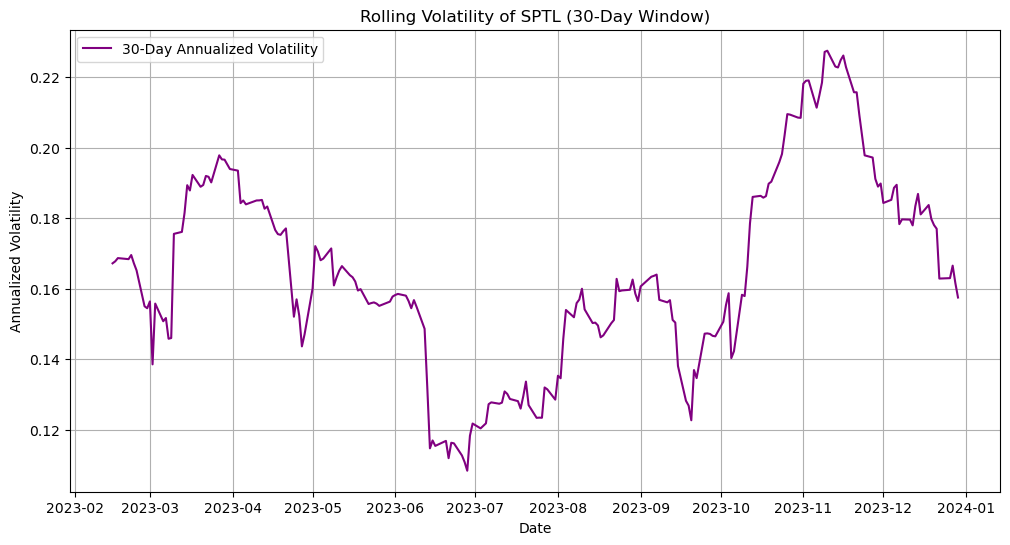

In [263]:
# Calculate Volatility of SPTL

daily_volatility = merged_data['Daily Return'].std()

annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility: {:.4f}".format(daily_volatility))
print("Annualized Volatility: {:.2%}".format(annual_volatility))

rolling_window = 30
merged_data['Rolling Volatility'] = merged_data['Daily Return'].rolling(window=rolling_window).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
plt.plot(merged_data['Date'], merged_data['Rolling Volatility'], label=f'{rolling_window}-Day Annualized Volatility', color='purple')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.title('Rolling Volatility of SPTL (30-Day Window)')
plt.legend()
plt.grid(True)
plt.show()


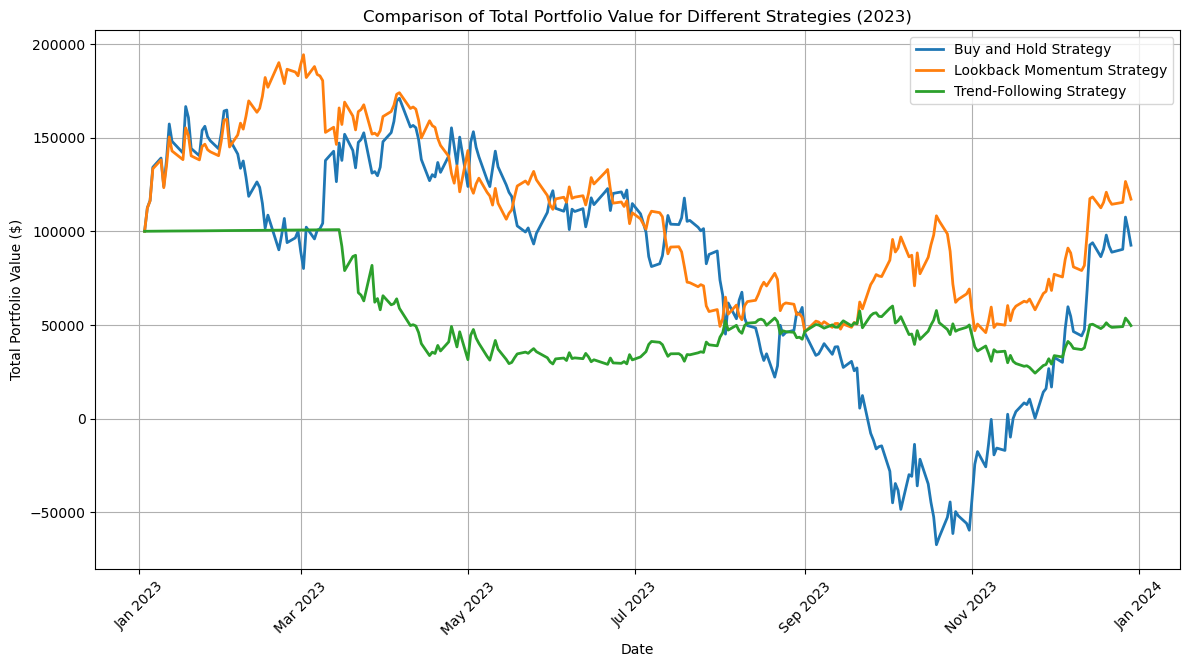

In [264]:
plt.figure(figsize=(14, 7))

plt.plot(merged_data['Date'], merged_data['V_total'], label='Buy and Hold Strategy', linewidth=2)
plt.plot(merged_data['Date'], merged_data['V_total_mom'], label='Lookback Momentum Strategy', linewidth=2)
plt.plot(merged_data['Date'], merged_data['V_total_tf'], label='Trend-Following Strategy', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Total Portfolio Value ($)')
plt.title('Comparison of Total Portfolio Value for Different Strategies (2023)')

plt.legend()
plt.grid(True)

ax = plt.gca()
date_formatter = mdates.DateFormatter('%b %Y')
ax.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=45)

plt.show()
